# Trader Workflow Example
## Using SPY ETF and Google (GOOGL) Stock

This notebook demonstrates a complete trading workflow using the Trader class with:
- **SPY**: S&P 500 ETF (popular market benchmark)
- **GOOGL**: Alphabet Inc. Class A shares

## 1. Setup and Initialization

In [29]:
from st.trader import Trader
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 2)

%matplotlib inline

In [2]:
# Initialize trader with a universe containing SPY and GOOGL
trader = Trader.with_universe(
    tickers=['SPY', 'GOOGL'],
    start_date='2023-01-01',
    end_date='2024-12-31',
    auto_download=True
)

trader

2025-12-09 00:57:35 - st.trader.trader - INFO - Trader initialized


Trader(universe=2 tickers, portfolio=0 positions, value=$100,000.00)

## 2. Universe Management

In [3]:
# View universe summary
universe_summary = trader.get_universe_summary()
print("Universe Summary:")
for key, value in universe_summary.items():
    print(f"  {key}: {value}")

Universe Summary:
  num_tickers: 2
  tickers: ['GOOGL', 'SPY']
  sectors: None
  filters: {'min_volume': None, 'min_price': None, 'max_price': None}
  has_metadata: False
  metadata_count: 0


In [4]:
# Get stock information for both tickers
for ticker in ['SPY', 'GOOGL']:
    info = trader.get_stock_info(ticker)
    print(f"  {ticker}: {info}")

  SPY: name='SPDR S&P 500 ETF' sector='Unknown' currency='USD' exchange='PCX'
  GOOGL: name='Alphabet Inc.' sector='Communication Services' currency='USD' exchange='NMS'


## 3. Data Retrieval and Analysis

In [5]:
# Get historical data for SPY
spy_data = trader.get_data('SPY')
print("SPY Data:")
print(spy_data.head())
print(f"\nShape: {spy_data.shape}")

2025-12-09 00:57:35 - st.data.data_manager - INFO - Loaded 501 rows for SPY from /Users/coolmajor/PycharmProjects/systematic_trading/st/data/historical/SPY.csv
SPY Data:
              Open    High     Low   Close     Volume
Date                                                 
2023-01-03  370.57  372.56  364.27  367.15   74850700
2023-01-04  369.43  372.03  366.36  369.99   85934100
2023-01-05  368.02  368.13  365.16  365.76   76970500
2023-01-06  368.88  375.28  365.79  374.15  104189600
2023-01-09  376.36  379.57  373.75  373.94   73978100

Shape: (501, 5)


In [6]:
# Get historical data for GOOGL
googl_data = trader.get_data('GOOGL')
print("GOOGL Data:")
print(googl_data.head())
print(f"\nShape: {googl_data.shape}")

2025-12-09 00:57:35 - st.data.data_manager - WARNING - Data file not found for GOOGL: /Users/coolmajor/PycharmProjects/systematic_trading/st/data/historical/GOOGL.csv
2025-12-09 00:57:35 - st.trader.trader - INFO - Downloading data for GOOGL
2025-12-09 00:57:35 - st.data.data_manager - INFO - Downloading GOOGL from 2023-01-01 to 2024-12-31
2025-12-09 00:57:35 - st.data.data_manager - INFO - Saved GOOGL data to /Users/coolmajor/PycharmProjects/systematic_trading/st/data/historical/GOOGL.csv
2025-12-09 00:57:35 - st.data.data_manager - INFO - Downloaded 501 rows for GOOGL
GOOGL Data:
             Open   High    Low  Close    Volume
Date                                            
2023-01-03  88.98  90.43  87.91  88.51  28131200
2023-01-04  89.73  90.03  86.67  87.48  34854800
2023-01-05  86.87  86.97  85.31  85.61  27194400
2023-01-06  86.20  87.09  84.28  86.74  41381500
2023-01-09  87.75  89.43  87.26  87.42  29003900

Shape: (501, 5)


In [7]:
# Get data summary for both tickers
spy_summary = trader.get_data_summary('SPY')
googl_summary = trader.get_data_summary('GOOGL')

print("\nSPY Data Summary:")
for key, value in spy_summary.items():
    print(f"  {key}: {value}")

print("\nGOOGL Data Summary:")
for key, value in googl_summary.items():
    print(f"  {key}: {value}")


SPY Data Summary:
  ticker: SPY
  start: 2023-01-03 00:00:00
  end: 2024-12-30 00:00:00
  rows: 501
  close_mean: 473.7540509800711
  close_std: 66.9619211496392
  volume_mean: 69647465.26946108
  high: 601.7541524804552
  low: 364.2680909295635

GOOGL Data Summary:
  ticker: GOOGL
  start: 2023-01-03 00:00:00
  end: 2024-12-30 00:00:00
  rows: 501
  close_mean: 140.4250013461846
  close_std: 27.368646728846574
  volume_mean: 30106915.768463075
  high: 200.76546017959686
  low: 84.2787216281847


## 4. Data Quality Validation

In [30]:
# Check data quality for the universe
validation = trader.validate_universe_data()
pprint(validation)

{'GOOGL': {'end_date': '2024-12-30 00:00:00',
           'missing_values': {'Close': 0,
                              'High': 0,
                              'Low': 0,
                              'Open': 0,
                              'Volume': 0},
           'price_anomalies': 0,
           'rows': 501,
           'start_date': '2023-01-03 00:00:00',
           'status': 'ok',
           'ticker': 'GOOGL',
           'zero_volume_days': 0},
 'SPY': {'end_date': '2024-12-30 00:00:00',
         'missing_values': {'Close': 0,
                            'High': 0,
                            'Low': 0,
                            'Open': 0,
                            'Volume': 0},
         'price_anomalies': 0,
         'rows': 501,
         'start_date': '2023-01-03 00:00:00',
         'status': 'ok',
         'ticker': 'SPY',
         'zero_volume_days': 0}}


## 5. Price Visualization

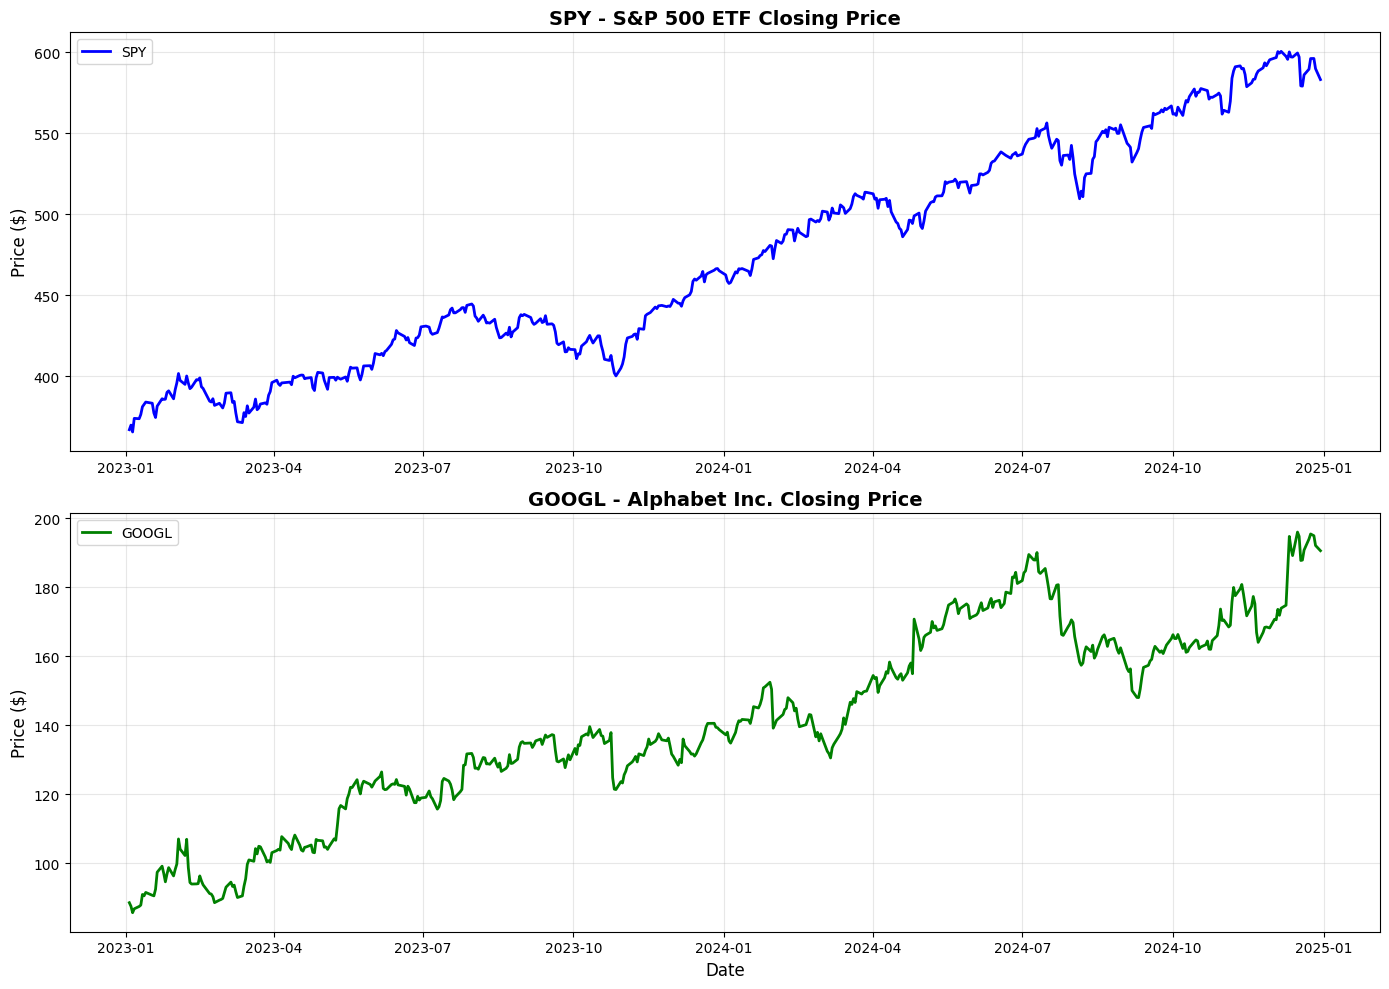

In [9]:
# Plot closing prices
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# SPY plot
axes[0].plot(spy_data.index, spy_data['Close'], label='SPY', color='blue', linewidth=2)
axes[0].set_title('SPY - S&P 500 ETF Closing Price', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# GOOGL plot
axes[1].plot(googl_data.index, googl_data['Close'], label='GOOGL', color='green', linewidth=2)
axes[1].set_title('GOOGL - Alphabet Inc. Closing Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

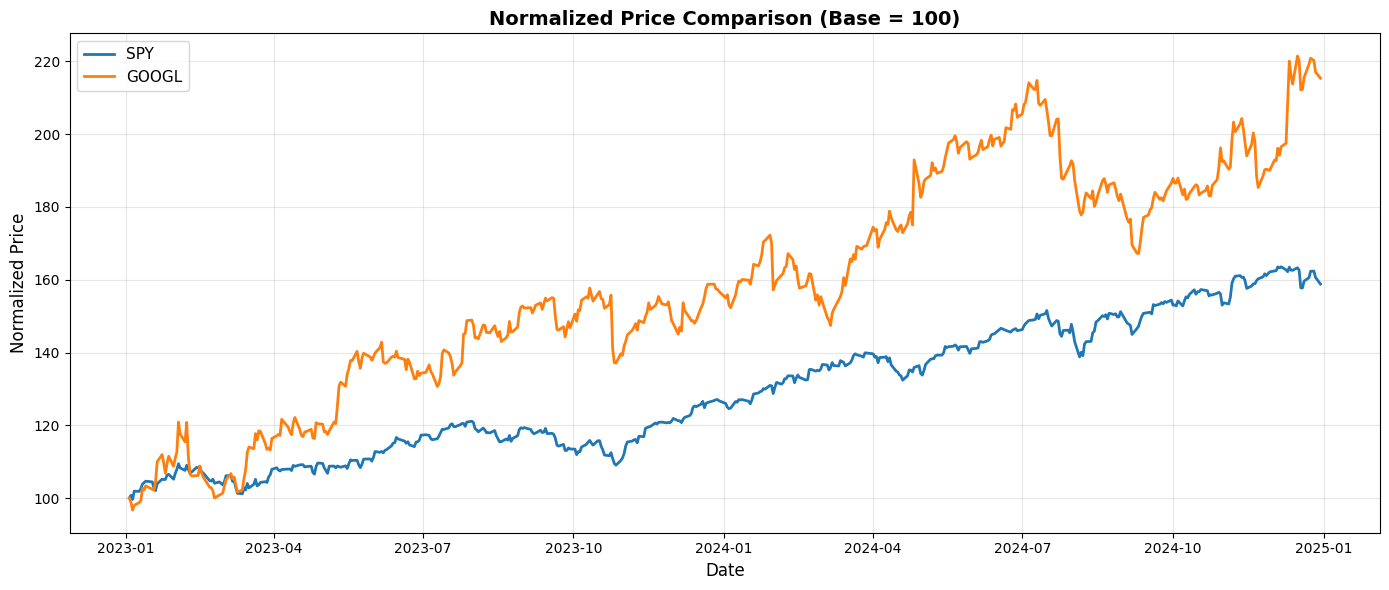

In [10]:
# Compare normalized prices (rebased to 100)
prices = trader.get_close_prices(['SPY', 'GOOGL'])
normalized_prices = (prices / prices.iloc[0]) * 100

plt.figure(figsize=(14, 6))
plt.plot(normalized_prices.index, normalized_prices['SPY'], label='SPY', linewidth=2)
plt.plot(normalized_prices.index, normalized_prices['GOOGL'], label='GOOGL', linewidth=2)
plt.title('Normalized Price Comparison (Base = 100)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Price', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Returns Analysis

In [11]:
# Calculate daily returns
returns = trader.calculate_returns(['SPY', 'GOOGL'])

print("Daily Returns Statistics:")
print("=" * 60)
print(returns.describe())

Daily Returns Statistics:
            SPY     GOOGL
count  5.00e+02  5.00e+02
mean   9.58e-04  1.70e-03
std    8.08e-03  1.84e-02
min   -2.98e-02 -9.51e-02
25%   -3.23e-03 -8.84e-03
50%    9.63e-04  3.02e-03
75%    6.00e-03  1.11e-02
max    2.49e-02  1.02e-01


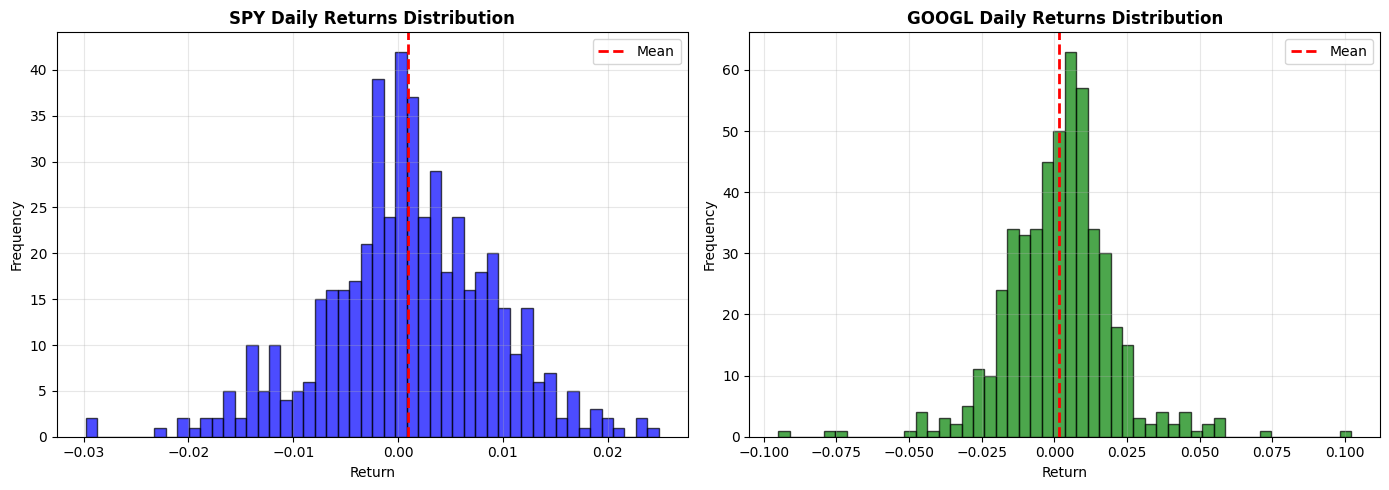

In [12]:
# Plot returns distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SPY returns histogram
axes[0].hist(returns['SPY'].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('SPY Daily Returns Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Return', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(returns['SPY'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GOOGL returns histogram
axes[1].hist(returns['GOOGL'].dropna(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('GOOGL Daily Returns Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Return', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].axvline(returns['GOOGL'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Calculate correlation
correlation_matrix = trader.calculate_correlation_matrix(['SPY', 'GOOGL'])

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Calculate cumulative returns
cumulative_returns = (1 + returns).cumprod()

print("\nTotal Returns:")
print(f"SPY: {(cumulative_returns['SPY'].iloc[-1] - 1) * 100:.2f}%")
print(f"GOOGL: {(cumulative_returns['GOOGL'].iloc[-1] - 1) * 100:.2f}%")


Correlation Matrix:
        SPY  GOOGL
SPY    1.00   0.58
GOOGL  0.58   1.00

Total Returns:
SPY: 58.82%
GOOGL: 115.36%


## 7. Portfolio Trading Simulation

In [14]:
# Get latest prices
latest_prices = trader.get_latest_prices(['SPY', 'GOOGL'])
print("Latest Prices:")
for ticker, price in latest_prices.items():
    print(f"  {ticker}: ${price:,.2f}")

Latest Prices:
  SPY: $583.11
  GOOGL: $190.62


In [15]:
# Buy SPY shares
print("\nBuying 100 shares of SPY...")
trader.buy('SPY', quantity=100)

# Buy GOOGL shares
print("Buying 50 shares of GOOGL...")
trader.buy('GOOGL', quantity=50)

print("\nTrades executed successfully!")


Buying 100 shares of SPY...
2025-12-09 00:57:36 - st.data.ticker_collection - INFO - Added SPY to Portfolio
2025-12-09 00:57:36 - st.data.portfolio - INFO - Added position: 100 shares of SPY at $583.11
Buying 50 shares of GOOGL...
2025-12-09 00:57:36 - st.data.ticker_collection - INFO - Added GOOGL to Portfolio
2025-12-09 00:57:36 - st.data.portfolio - INFO - Added position: 50 shares of GOOGL at $190.62

Trades executed successfully!


In [16]:
# View portfolio summary
portfolio_summary = trader.get_portfolio_summary()

print("\nPortfolio Summary:")
print("=" * 60)
print(f"Total Value: ${portfolio_summary['total_value']:,.2f}")
print(f"Cash: ${portfolio_summary['cash']:,.2f} ({portfolio_summary['cash_weight']:.1f}%)")
print(f"Positions Value: ${portfolio_summary['positions_value']:,.2f}")
print(f"Number of Positions: {portfolio_summary['num_positions']}")
print(f"Total Return: {trader.portfolio.total_return:.2f}%")
print(f"Total Unrealized P&L: ${portfolio_summary['total_unrealized_pnl']:,.2f}")

print("\nPositions:")
print("-" * 60)
for ticker, pos in portfolio_summary['positions'].items():
    print(f"{ticker}:")
    print(f"  Quantity: {pos['quantity']:.0f} shares")
    print(f"  Avg Entry: ${pos['avg_entry']:.2f}")
    print(f"  Current Price: ${pos['current_price']:.2f}")
    print(f"  Market Value: ${pos['market_value']:,.2f}")
    print(f"  Unrealized P&L: ${pos['unrealized_pnl']:,.2f} ({pos['unrealized_pnl_pct']:.2f}%)")
    print(f"  Weight: {pos['weight']:.2f}%")
    print()

2025-12-09 00:57:36 - st.data.portfolio - INFO - Updated prices for 2 positions

Portfolio Summary:
Total Value: $100,000.00
Cash: $32,158.01 (32.2%)
Positions Value: $67,841.99
Number of Positions: 2
Total Return: 0.00%
Total Unrealized P&L: $0.00

Positions:
------------------------------------------------------------
SPY:
  Quantity: 100 shares
  Avg Entry: $583.11
  Current Price: $583.11
  Market Value: $58,311.06
  Unrealized P&L: $0.00 (0.00%)
  Weight: 58.31%

GOOGL:
  Quantity: 50 shares
  Avg Entry: $190.62
  Current Price: $190.62
  Market Value: $9,530.93
  Unrealized P&L: $0.00 (0.00%)
  Weight: 9.53%



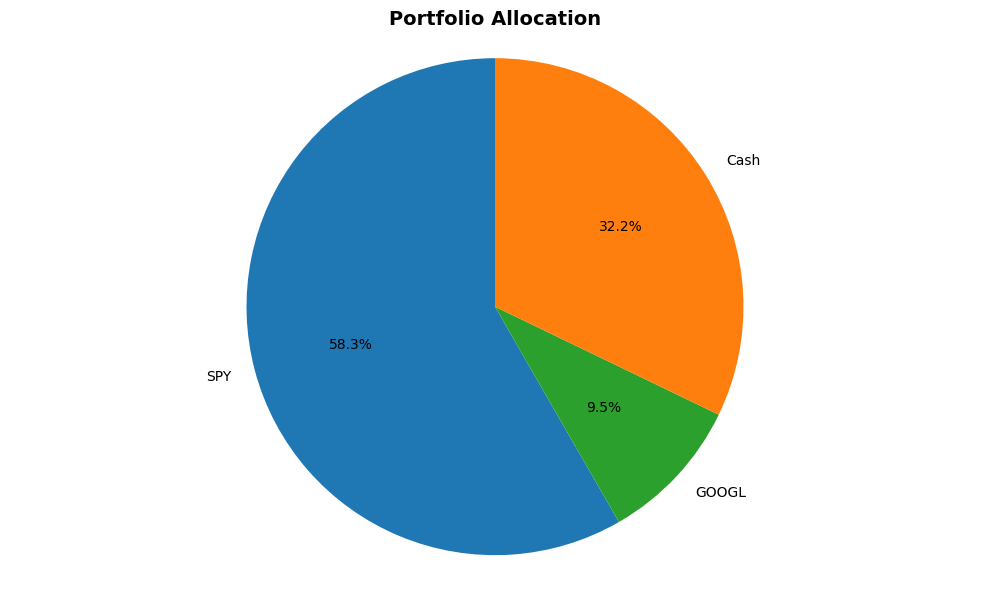

In [17]:
# Visualize portfolio allocation
positions = portfolio_summary['positions']
labels = list(positions.keys()) + ['Cash']
values = [pos['market_value'] for pos in positions.values()] + [portfolio_summary['cash']]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

plt.figure(figsize=(10, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Portfolio Allocation', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 8. Portfolio Operations

In [18]:
# Sell some SPY shares
print("Selling 50 shares of SPY...")
pnl = trader.sell('SPY', quantity=50)
print(f"Realized P&L from sale: ${pnl:,.2f}")

# View updated portfolio
print("\nUpdated Portfolio Value: ${:,.2f}".format(trader.get_portfolio_value()))

Selling 50 shares of SPY...
2025-12-09 00:57:36 - st.data.portfolio - INFO - Removed 50 shares of SPY
2025-12-09 00:57:36 - st.data.portfolio - INFO - Reduced position in SPY by 50 shares, realized P&L: $0.00
Realized P&L from sale: $0.00
2025-12-09 00:57:36 - st.data.portfolio - INFO - Updated prices for 2 positions

Updated Portfolio Value: $100,000.00


In [19]:
# Export portfolio to DataFrame
portfolio_df = trader.portfolio.to_dataframe()
print("\nPortfolio DataFrame:")
print(portfolio_df)


Portfolio DataFrame:
  ticker  quantity  avg_entry_price  current_price  market_value  cost_basis  \
0    SPY      50.0           583.11         583.11      29155.53    29155.53   
1  GOOGL      50.0           190.62         190.62       9530.93     9530.93   

   unrealized_pnl  unrealized_pnl_pct  weight               last_updated  
0             0.0                 0.0   29.16 2025-12-09 00:57:36.237722  
1             0.0                 0.0    9.53 2025-12-09 00:57:36.237723  


## 9. Generate Complete Report

In [20]:
# Generate and display comprehensive report
report = trader.generate_report()
print(report)

2025-12-09 00:57:36 - st.data.portfolio - INFO - Updated prices for 2 positions
TRADING REPORT
Generated: 2025-12-09 00:57:36

UNIVERSE:
------------------------------------------------------------
  Size: 2 tickers
  Tickers: GOOGL, SPY

PORTFOLIO:
------------------------------------------------------------
  Total Value: $100,000.00
  Cash: $61,313.54 (61.3%)
  Positions Value: $38,686.46
  Positions: 2
  Total Return: 0.00%
  Unrealized P&L: $0.00

POSITIONS:
------------------------------------------------------------
  SPY: 50 shares @ $583.11 | Current: $583.11 | P&L: $0.00 (0.0%) | Weight: 29.2%
  GOOGL: 50 shares @ $190.62 | Current: $190.62 | P&L: $0.00 (0.0%) | Weight: 9.5%

DATA CACHE:
------------------------------------------------------------
  Cached tickers: 2
  Cache TTL: 60 minutes


## 10. Export Data

In [21]:
# Export universe data
universe_file = trader.export_universe_data('spy_googl_universe.csv')
print(f"Universe data exported to: {universe_file}")

# Export portfolio data
portfolio_file = trader.export_portfolio_data('spy_googl_portfolio.csv')
print(f"Portfolio data exported to: {portfolio_file}")

2025-12-09 00:57:36 - st.trader.trader - INFO - Exported universe data to /Users/coolmajor/PycharmProjects/systematic_trading/st/data/historical/spy_googl_universe.csv
Universe data exported to: /Users/coolmajor/PycharmProjects/systematic_trading/st/data/historical/spy_googl_universe.csv
2025-12-09 00:57:36 - st.trader.trader - INFO - Exported portfolio to /Users/coolmajor/PycharmProjects/systematic_trading/st/data/historical/spy_googl_portfolio.csv
Portfolio data exported to: /Users/coolmajor/PycharmProjects/systematic_trading/st/data/historical/spy_googl_portfolio.csv


## Summary

This notebook demonstrated:
1. ✅ Initializing a Trader with SPY and GOOGL
2. ✅ Retrieving and analyzing historical data
3. ✅ Validating data quality
4. ✅ Visualizing prices and returns
5. ✅ Calculating correlations and performance metrics
6. ✅ Executing buy/sell trades
7. ✅ Managing portfolio positions
8. ✅ Generating reports and exporting data

### Key Insights:
- SPY provides broad market exposure with lower volatility
- GOOGL offers tech sector exposure with higher growth potential
- The correlation between SPY and GOOGL shows how individual tech stocks relate to the broader market
- Portfolio diversification helps manage risk across different asset types